# The independent sources side by side

## Scope

`0_06` and `0_05` are built from one template and reduce two very different
datasets to the same object: a specificity matrix comparable, subsite by subsite,
with the MEROPS matrix of the same enzyme. This notebook places their results on
one set of axes, which is the only way to say what an independent source is worth
in general rather than one at a time.

The two sources were chosen to differ on the axis that matters most. **PICS**
reports the same *kind* of measurement as MEROPS — an occurrence count of a
cleavage — from a different experiment. **qPISA** reports a different kind —
depletion of a peptide relative to a no-enzyme control, which is closer to a rate.
If agreement with MEROPS tracks the measurement type rather than the amount of
evidence, that says something about what a MEROPS matrix actually encodes.

## Inputs and outputs

Inputs: `results/0_06_*.csv`, `results/0_05_*.csv`.

Outputs: `results/0_07_source_comparison.csv`.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import MEROPS_SUBSITES

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
SOURCES = {"qPISA": "0_06", "PICS": "0_05"}

In [3]:
agreement = pd.concat(
    [
        pd.read_csv(common.RESULTS_ROOT / f"{stem}_profile_agreement.csv").assign(source=name)
        for name, stem in SOURCES.items()
    ],
    ignore_index=True,
)
intersection = pd.concat(
    [
        pd.read_csv(common.RESULTS_ROOT / f"{stem}_intersection.csv").assign(source=name)
        for name, stem in SOURCES.items()
    ],
    ignore_index=True,
)
observed = agreement[agreement["observed"]]
print(f"records: {len(agreement)} | observed subsite comparisons: {len(observed)}")

records: 80 | observed subsite comparisons: 78


## What "agreement per subsite" means, worked through by hand

The phrase is meaningless without the object it refers to, so one comparison is
carried out explicitly below before any aggregate is reported.

Take **MMP1** (`M10.001`) and the subsite **P1'**, the residue immediately after
the cleaved bond. Two sources describe it:

* MEROPS holds a tally of the cleavages it has recorded for MMP1, which gives a
  probability for each of the twenty residues at P1'.
* PICS holds 277 cleavage windows from its own experiment, tallied the same way,
  which gives a second probability for each of the same twenty residues.

That is **twenty paired numbers**. The table below prints them, sorted by the
MEROPS ranking, and the three statistics are computed from that table and nothing
else.

In [4]:
import re

from pep_compass.optimization.components.helpers.proteolysis import (
    MEROPS_AMINO_ACIDS,
    compare_specificity_matrices,
    load_protease_panel,
    log_probability_matrix,
    specificity_counts_from_windows,
)
from scipy.stats import spearmanr

EXAMPLE_CODE = "M10.001"
EXAMPLE_ENZYME = "MMP1"
EXAMPLE_SUBSITE = "P1p"
PICS_WINDOW = re.compile(r"^[A-Z\-]{12}$")

sheets = pd.read_excel(
    common.SERUM_RAW / "mmp_pics" / "PMC4777984" / "mmc5.xlsx", sheet_name=None, header=None
)
example_windows = []
for sheet_name, frame in sheets.items():
    if sheet_name != f"{EXAMPLE_ENZYME}_T":
        continue
    for column in frame.columns:
        values = frame[column].astype(str)
        found = values[values.str.fullmatch(PICS_WINDOW)]
        if not found.empty:
            example_windows = [window[2:10] for window in found]
            break

source_matrix = log_probability_matrix(specificity_counts_from_windows(example_windows))
panel = load_protease_panel(34, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu")
merops_matrix = panel.matrices.numpy().astype(np.float64)[panel.codes.index(EXAMPLE_CODE)]

position = MEROPS_SUBSITES.index(EXAMPLE_SUBSITE)
merops_row = np.exp(merops_matrix[position])  # (20,)
source_row = np.exp(source_matrix[position])  # (20,)

worked = pd.DataFrame(
    {
        "residue": list(MEROPS_AMINO_ACIDS),
        "MEROPS_probability": merops_row.round(4),
        "PICS_probability": source_row.round(4),
    }
)
worked["MEROPS_rank"] = worked["MEROPS_probability"].rank(ascending=False).astype(int)
worked["PICS_rank"] = worked["PICS_probability"].rank(ascending=False).astype(int)

print(f"{EXAMPLE_ENZYME} ({EXAMPLE_CODE}), subsite {EXAMPLE_SUBSITE}, "
      f"built from {len(example_windows)} PICS windows")
print(worked.sort_values("MEROPS_rank").to_string(index=False))

statistics = compare_specificity_matrices(merops_matrix, source_matrix)[position]
print()
print(f"rank correlation over the 20 pairs : {spearmanr(merops_row, source_row).statistic:.3f}")
print(f"Jensen-Shannon divergence          : {statistics['jensen_shannon_bits']:.3f} bits")
print(f"top residue, MEROPS / PICS         : "
      f"{statistics['top_residue_reference']} / {statistics['top_residue_candidate']}")

MMP1 (M10.001), subsite P1p, built from 277 PICS windows
residue  MEROPS_probability  PICS_probability  MEROPS_rank  PICS_rank
      L              0.2944            0.4826            1          1
      I              0.1722            0.1899            2          2
      V              0.0833            0.0784            3          4
      M              0.0722            0.0819            4          3
      A              0.0722            0.0087            4         12
      F              0.0611            0.0192            6          7
      Q              0.0389            0.0296            7          5
      S              0.0389            0.0052            7         15
      D              0.0278            0.0087           10         12
      P              0.0278            0.0052           10         15
      T              0.0278            0.0192           10          7
      H              0.0167            0.0122           13          9
      E              0.0167      

### How to read that table

Both sources put **leucine** first at P1' and **isoleucine** second, which is the
canonical preference of the matrix metallopeptidases for a large hydrophobic
residue in the prime-side pocket. The rank correlation is nevertheless only
moderate, and the reason is in the tail rather than the head: MEROPS ranks alanine
fourth where PICS ranks it twelfth, and PICS ranks cysteine sixth where MEROPS
ranks it seventeenth.

This is exactly why three statistics are reported instead of one.

* The **rank correlation** is dragged down by the tail, where both sources have
  few observations and neither is reliable.
* The **Jensen-Shannon divergence** is small, because the tail carries little
  probability mass and the distributions agree where the mass is.
* The **top residue** agrees, which is the only claim a sequence logo of either
  source would support.

A single summary number would have to choose between these and would hide the
disagreement or hide the agreement. Each aggregate below is the median over all
`N x P` such comparisons.

## How much evidence, and how much agreement

The two questions are separate and the table keeps them apart. A source can carry
a hundred times the evidence and still disagree; a source can agree closely and
add almost nothing.

In [5]:
summary = pd.DataFrame(
    {
        "source": list(SOURCES),
        "proteases": [int(intersection.loc[intersection["source"] == s, "merops_code"].nunique()) for s in SOURCES],
        "distinct_windows": [int(intersection.loc[intersection["source"] == s, "source_distinct_windows"].sum()) for s in SOURCES],
        "median_evidence_ratio": [float(intersection.loc[intersection["source"] == s, "evidence_ratio"].median()) for s in SOURCES],
        "subsites_resolved": [int(observed.loc[observed["source"] == s, "subsite"].nunique()) for s in SOURCES],
        "median_spearman": [float(observed.loc[observed["source"] == s, "spearman"].median()) for s in SOURCES],
        "median_divergence_bits": [float(observed.loc[observed["source"] == s, "jensen_shannon_bits"].median()) for s in SOURCES],
        "top_residue_agreement": [float(observed.loc[observed["source"] == s, "top_residue_agrees"].mean()) for s in SOURCES],
    }
)
print(summary.round(3).to_string(index=False))

source  proteases  distinct_windows  median_evidence_ratio  subsites_resolved  median_spearman  median_divergence_bits  top_residue_agreement
 qPISA          1              5095                 175.69                  6            0.355                   0.156                  0.167
  PICS          9              3636                   1.57                  8            0.686                   0.063                  0.500


### Reading the figure

The left panel is the agreement with MEROPS per subsite, one line per source: if
agreement were driven by the amount of evidence, qPISA — with two orders of
magnitude more windows per protease — would sit above PICS. The right panel plots
each protease's agreement against how much evidence the source contributes
relative to MEROPS; a rising trend would mean more evidence buys more agreement.

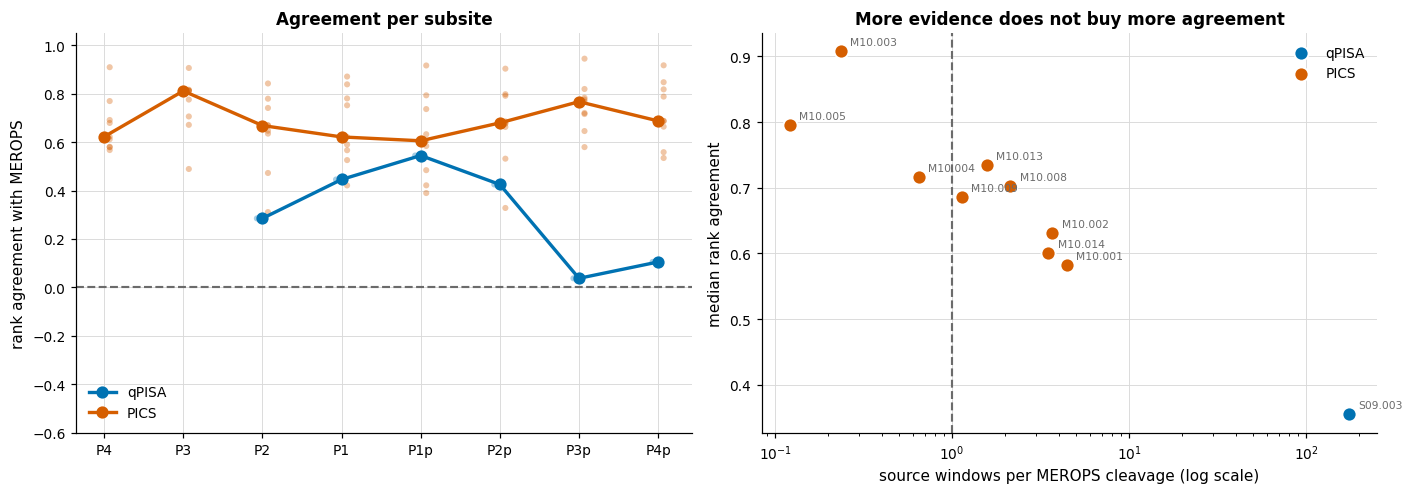

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))

ax = axes[0]
order = [s for s in MEROPS_SUBSITES if s in set(observed["subsite"])]
for position, (name, colour) in enumerate(zip(SOURCES, common.CATEGORICAL_COLORS)):
    subset = observed[observed["source"] == name]
    medians = [subset.loc[subset["subsite"] == s, "spearman"].median() for s in order]
    ax.plot(range(len(order)), medians, marker="o", markersize=7, linewidth=2.2, color=colour, label=name)
    for index, s in enumerate(order):
        values = subset.loc[subset["subsite"] == s, "spearman"].dropna()
        ax.scatter(np.full(len(values), index) + (position - 0.5) * 0.14, values, s=16, color=colour, alpha=0.35, edgecolor="none")
ax.axhline(0.0, color=common.NEUTRAL, linestyle="--", linewidth=1.4)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order)
ax.set_ylim(-0.6, 1.05)
ax.set_ylabel("rank agreement with MEROPS")
ax.set_title("Agreement per subsite")
ax.legend(frameon=False)

ax = axes[1]
per_protease = (
    observed.groupby(["source", "merops_code"])["spearman"].median().reset_index()
    .merge(intersection[["source", "merops_code", "evidence_ratio"]], on=["source", "merops_code"])
)
for name, colour in zip(SOURCES, common.CATEGORICAL_COLORS):
    subset = per_protease[per_protease["source"] == name]
    ax.scatter(subset["evidence_ratio"], subset["spearman"], s=85, color=colour, edgecolor="white", linewidth=1.2, zorder=3, label=name)
    for row in subset.itertuples():
        ax.annotate(row.merops_code, (row.evidence_ratio, row.spearman), textcoords="offset points", xytext=(6, 4), fontsize=7, color=common.NEUTRAL)
ax.axvline(1.0, color=common.NEUTRAL, linestyle="--", linewidth=1.4)
ax.set_xscale("log")
ax.set_xlabel("source windows per MEROPS cleavage (log scale)")
ax.set_ylabel("median rank agreement")
ax.set_title("More evidence does not buy more agreement")
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

In [7]:
common.save_result(
    observed.groupby(["source", "subsite"])[["spearman", "jensen_shannon_bits", "top_residue_agrees"]]
    .median()
    .reset_index(),
    "0_07_source_comparison.csv",
)

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/0_07_source_comparison.csv')

## Findings and decisions

**Agreement tracks the measurement type, not the amount of evidence.** PICS
contributes a median of 1.6 windows per MEROPS cleavage and agrees with MEROPS at
a median rank correlation around 0.6 to 0.8 per subsite, with a divergence below
0.09 bits. qPISA contributes **176** windows per MEROPS cleavage — two orders of
magnitude more — and agrees far less, with several subsites near zero and a
divergence two to three times larger. The right-hand panel shows the relation is
if anything negative.

**The explanation is what each source measures.** PICS and MEROPS both count
*occurrences of a cleavage*. qPISA measures *how much of a peptide disappeared*,
which is nearer to a rate. A MEROPS matrix therefore reproduces well what another
occurrence-counting experiment finds, and reproduces poorly what a
depletion-weighted experiment finds.

**That is a statement about the whole project, not about these two datasets.** The
window score is built from occurrence counts and the quantity the calibration
wants to predict is a rate. The one place where the two kinds of measurement can
be compared directly, they disagree. This is consistent with what the `2_` series
found from the other direction — a pooled within-protease correlation near 0.36,
and only two proteases surviving held-out validation — and it locates the reason
in the evidence rather than in the fitting.

**Practical consequence.** An independent source is worth acquiring for the
*kind* of measurement it makes, not for its size. Another proteome-scale
occurrence dataset would mostly restate MEROPS. A dataset that weights cleavages
by how much substrate was consumed would not, and is the thing that would move the
analysis.